In [ ]:
;# Importing important libraries
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
os.chdir('/content/drive/My Drive/microgrid datasets data')

In [ ]:
os.getcwd()

'/content/drive/My Drive/microgrid datasets data'

Rye Microgrid Data

In [ ]:
rye_data = pd.read_csv('train.csv')
rye_data

,time,pv_production,wind_production,consumption,spot_market_price,precip_1h:mm,precip_type:idx,prob_precip_1h:p,clear_sky_rad:W,clear_sky_energy_1h:J,...,t_50m:C,relative_humidity_50m:p,dew_point_50m:C,wind_speed_50m:ms,wind_dir_50m:d,t_100m:C,relative_humidity_100m:p,dew_point_100m:C,wind_speed_100m:ms,wind_dir_100m:d
0,2020-01-01 13:00:00,0.0,40.59,26.514689,0.28969,0.0,0.0,1.0,10.0,64826.0,...,8.4,60.7,1.3,8.4,246.3,8.3,60.3,1.0,10.4,247.3
1,2020-01-01 14:00:00,0.0,67.86,28.326960,0.29561,0.0,0.0,1.0,0.0,8961.1,...,8.4,61.6,1.5,8.0,252.3,8.4,60.7,1.2,10.0,252.1
2,2020-01-01 15:00:00,0.0,116.68,23.682207,0.30044,0.0,0.0,1.0,0.0,0.0,...,8.5,60.3,1.3,9.6,254.1,8.4,59.6,1.0,11.7,253.8
3,2020-01-01 16:00:00,0.0,120.22,25.354782,0.29975,0.0,0.0,1.0,0.0,0.0,...,8.4,63.9,2.0,12.1,254.6,8.3,63.4,1.7,14.3,254.2
4,2020-01-01 17:00:00,0.0,109.86,23.861942,0.29650,0.0,0.0,1.0,0.0,0.0,...,7.2,78.9,3.8,11.7,249.5,7.1,77.9,3.5,13.9,249.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9510,2021-01-31 19:00:00,0.0,21.98,44.422658,0.60243,0.0,0.0,1.0,0.0,0.0,...,-3.2,93.1,-4.2,4.8,231.2,-3.1,91.6,-4.3,6.0,238.3
9511,2021-01-31 20:00:00,0.0,9.60,45.167707,0.53335,0.0,0.0,1.0,0.0,0.0,...,-3.5,94.1,-4.3,4.9,224.9,-3.3,92.1,-4.4,6.2,231.8
9512,2021-01-31 21:00:00,0.0,22.61,32.476198,0.51195,0.0,0.0,1.0,0.0,0.0,...,-3.6,93.0,-4.6,4.7,224.5,-3.3,90.6,-4.6,6.0,231.7
9513,2021-01-31 22:00:00,0.0,21.70,28.561791,0.47122,0.0,0.0,1.0,0.0,0.0,...,-3.7,92.1,-4.8,4.5,222.8,-3.4,89.5,-4.9,5.8,231.1


In [ ]:
rye_data.columns

Index(['time', 'pv_production', 'wind_production', 'consumption',
       'spot_market_price', 'precip_1h:mm', 'precip_type:idx',
       'prob_precip_1h:p', 'clear_sky_rad:W', 'clear_sky_energy_1h:J',
       'diffuse_rad:W', 'diffuse_rad_1h:Wh', 'direct_rad:W',
       'direct_rad_1h:Wh', 'global_rad:W', 'global_rad_1h:Wh',
       'sunshine_duration_1h:min', 'sun_azimuth:d', 'sun_elevation:d',
       'low_cloud_cover:p', 'medium_cloud_cover:p', 'high_cloud_cover:p',
       'total_cloud_cover:p', 'effective_cloud_cover:p', 'temp',
       'relative_humidity_2m:p', 'dew_point_2m:C', 'wind_speed_2m:ms',
       'wind_dir_2m:d', 't_10m:C', 'relative_humidity_10m:p',
       'dew_point_10m:C', 'wind_speed_10m:ms', 'wind_dir_10m:d', 't_50m:C',
       'relative_humidity_50m:p', 'dew_point_50m:C', 'wind_speed_50m:ms',
       'wind_dir_50m:d', 't_100m:C', 'relative_humidity_100m:p',
       'dew_point_100m:C', 'wind_speed_100m:ms', 'wind_dir_100m:d'],
      dtype='object')

#Solar Generation Functions

In [ ]:
def calculate_solar_energy(irradiance_w_per_m2, area, efficiency):
    """
    Calculate estimated solar energy generated from PV cells.

    Parameters:
    irradiance_w_per_m2 (float): Solar irradiance in W/m²
    height_m (float): Height of the PV panel in meters
    width_m (float): Width of the PV panel in meters
    efficiency (float): Efficiency of the PV panel (0 < efficiency <= 1)

    Returns:
    float: Estimated energy in watts
    """
    energy_generated = irradiance_w_per_m2 * area * efficiency / 3600  # in kWh
    return energy_generated


#Load Generation Functions

In [ ]:
x_rye=rye_data[['t_50m:C','time']]
x_rye["time"] = pd.to_datetime(x_rye["time"])
x_rye['temp']=x_rye['t_50m:C']
x_rye.drop(columns='t_50m:C', inplace=True)
x_rye["hour"] = x_rye["time"].dt.hour
x_rye["day_of_year"] = x_rye["time"].dt.dayofyear
y_rye=rye_data['consumption']/4

<ipython-input-8-92b6cc485b00>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x_rye["time"] = pd.to_datetime(x_rye["time"])
<ipython-input-8-92b6cc485b00>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x_rye['temp']=x_rye['t_50m:C']
<ipython-input-8-92b6cc485b00>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x_rye.dr

In [ ]:
x_train=x_rye.copy()
x_train.drop(columns='time', inplace=True)
y_train=y_rye.copy()
#y_train=y_train.rolling(6, min_periods=1).mean()

model = RandomForestRegressor()
model.fit(x_train, y_train)

y_train_pred = model.predict(x_train)

# Training metrics
print("Training:")
print("MAE:", mean_absolute_error(y_train, y_train_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_train, y_train_pred)))
print("R²:", r2_score(y_train, y_train_pred))

Training:
MAE: 0.27636864032970515
RMSE: 0.46281296128913835
R²: 0.9503817550987368


In [ ]:
importances = model.feature_importances_
feature_names = x_train.columns
for name, imp in zip(feature_names, importances):
    print(f"{name}: {imp}")

temp: 0.4242853739834377
hour: 0.3086687144416034
day_of_year: 0.267045911574959


In [ ]:
def generate_load(x, num_buildings=1, scale_factor=1):
  x=x.copy()
  x=x[['temperature_2m (°C)','time']]
  x['temp']=x['temperature_2m (°C)']
  x.drop(columns='temperature_2m (°C)', inplace=True)
  x["time"] = pd.to_datetime(x["time"])
  x["hour"] = x["time"].dt.hour
  x["day_of_year"] = x["time"].dt.dayofyear
  x.drop(columns='time', inplace=True)
  data=[]
  for i in range(len(x)):
    load=0
    house=model.predict(x.iloc[[i]])[0]
    for i in range(num_buildings):
      scale = np.random.normal(1, 0.2)
      noise = np.random.normal(0, 0.1, 1)
      load+=house*scale+noise
    data.append(load*scale_factor)
  return pd.DataFrame(data)

# Lac Megantic Dataset

In [ ]:
lac_megantic = pd.read_csv('LacMeganticWeatherData.csv', skiprows=3)
lac_megantic

,time,temperature_2m (°C),relative_humidity_2m (%),dew_point_2m (°C),apparent_temperature (°C),precipitation (mm),rain (mm),snowfall (cm),snow_depth (m),vapour_pressure_deficit (kPa),...,cloud_cover (%),surface_pressure (hPa),pressure_msl (hPa),wind_speed_10m (km/h),wind_speed_100m (km/h),wind_direction_10m (°),wind_direction_100m (°),wind_gusts_10m (km/h),shortwave_radiation (W/m²),shortwave_radiation_instant (W/m²)
0,2024-01-01T00:00,-8.4,68,-13.2,-13.5,0.0,0.0,0.0,0.10,0.10,...,6,960.4,1016.6,11.0,19.0,293,295,22.7,0.0,0.0
1,2024-01-01T01:00,-9.7,73,-13.6,-14.8,0.0,0.0,0.0,0.10,0.08,...,100,960.7,1017.2,10.6,16.8,294,293,22.3,0.0,0.0
2,2024-01-01T02:00,-9.8,73,-13.7,-14.8,0.0,0.0,0.0,0.10,0.08,...,100,960.6,1017.1,10.5,16.6,301,300,23.4,0.0,0.0
3,2024-01-01T03:00,-9.8,73,-13.8,-14.8,0.0,0.0,0.0,0.09,0.08,...,100,960.4,1016.9,10.5,15.7,301,302,23.0,0.0,0.0
4,2024-01-01T04:00,-9.6,71,-13.9,-14.5,0.0,0.0,0.0,0.09,0.09,...,100,960.5,1017.0,9.7,14.5,297,297,24.1,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8779,2024-12-31T19:00,2.5,79,-0.9,-1.6,0.0,0.0,0.0,0.15,0.16,...,100,957.1,1010.8,12.9,20.3,238,240,34.9,70.0,60.7
8780,2024-12-31T20:00,2.4,79,-0.9,-1.0,0.0,0.0,0.0,0.15,0.16,...,100,957.2,1010.9,8.1,14.3,235,237,25.6,53.0,38.3
8781,2024-12-31T21:00,1.6,83,-1.0,-1.2,0.0,0.0,0.0,0.15,0.12,...,100,957.5,1011.4,3.7,10.1,235,243,15.5,27.0,3.6
8782,2024-12-31T22:00,1.0,86,-1.1,-1.4,0.0,0.0,0.0,0.15,0.10,...,98,957.9,1012.0,1.0,4.8,158,211,6.5,0.0,0.0


In [ ]:
area = 24 * 7 + 20 * 13 + 90 * 100
lac_megantic['pv_production'] = calculate_solar_energy(irradiance_w_per_m2=lac_megantic['shortwave_radiation_instant (W/m²)'], area=area, efficiency=0.25)
#Cell may take a few minutes to run
lac_megantic['consumption'] = generate_load(lac_megantic, num_buildings=30, scale_factor=1.5)
lac_megantic['price'] = .0674

In [ ]:
lac_megantic.describe()

,temperature_2m (°C),relative_humidity_2m (%),dew_point_2m (°C),apparent_temperature (°C),precipitation (mm),rain (mm),snowfall (cm),snow_depth (m),vapour_pressure_deficit (kPa),et0_fao_evapotranspiration (mm),...,pressure_msl (hPa),wind_speed_10m (km/h),wind_speed_100m (km/h),wind_direction_10m (°),wind_direction_100m (°),wind_gusts_10m (km/h),shortwave_radiation (W/m²),shortwave_radiation_instant (W/m²),pv_production,consumption
count,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8280.000000,8784.000000,8784.000000,...,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000
mean,6.283732,77.031193,2.146744,3.511305,0.130043,0.096403,0.023652,0.139498,0.297910,0.084089,...,1015.493739,12.004577,21.315801,215.064663,217.447746,27.015972,150.396516,149.585109,97.936695,228.334111
std,10.977782,16.902233,10.796992,13.127662,0.536726,0.503883,0.132976,0.182401,0.371123,0.130780,...,8.904878,5.760356,9.207391,83.489592,84.007685,13.033820,225.626771,226.318033,148.175446,85.529923
min,-22.500000,14.000000,-26.400000,-27.100000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,978.100000,0.000000,0.000000,1.000000,0.000000,2.500000,0.000000,0.000000,0.000000,77.605893
25%,-1.900000,66.000000,-5.900000,-6.600000,0.000000,0.000000,0.000000,0.000000,0.060000,0.000000,...,1010.100000,7.900000,15.300000,162.000000,163.000000,16.900000,0.000000,0.000000,0.000000,163.700715
50%,6.400000,81.000000,2.500000,3.000000,0.000000,0.000000,0.000000,0.000000,0.150000,0.020000,...,1015.600000,11.200000,20.600000,239.000000,244.000000,25.200000,7.000000,0.000000,0.000000,212.764345
75%,15.400000,90.000000,11.500000,14.500000,0.000000,0.000000,0.000000,0.300000,0.380000,0.100000,...,1021.000000,15.300000,26.800000,280.000000,282.000000,34.600000,244.250000,238.225000,155.971201,280.001247
max,30.900000,100.000000,22.700000,34.700000,16.100000,16.100000,3.430000,0.630000,2.480000,0.650000,...,1049.400000,43.300000,73.800000,360.000000,360.000000,97.200000,953.000000,955.600000,625.652556,777.483106


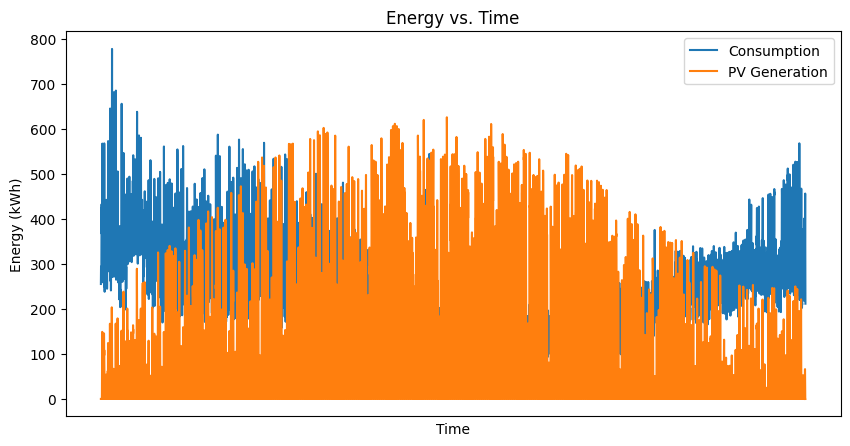

In [ ]:
plt.figure(figsize=(8,6))
plt.plot(lac_megantic['time'], lac_megantic['consumption'], label='Energy Consumption')
plt.plot(lac_megantic['time'], lac_megantic['pv_production'], label='PV Generation')
plt.title('Energy vs. Time')
plt.xlabel('Time')
plt.xticks([])
plt.ylabel('Maximum Power (kW)')
plt.legend()
plt.show()

From Lac Megantic's Website

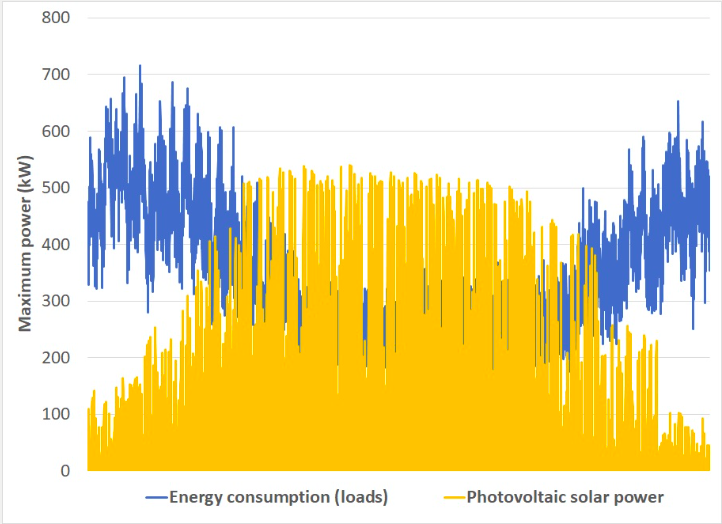

In [ ]:
lac_megantic.to_csv("LacMeganticDataTrain.csv")

In [ ]:
LM_test=pd.read_csv('LacMeganticWeatherDataTest.csv', skiprows=3)
area = 24 * 7 + 20 * 13 + 90 * 100
LM_test['pv_production'] = calculate_solar_energy(irradiance_w_per_m2=LM_test['shortwave_radiation_instant (W/m²)'], area=area, efficiency=0.25)
#Cell may take a few minutes to run
LM_test['consumption'] = generate_load(LM_Test, num_buildings=30, scale_factor=1.5)
LM_test['price'] = .0674
LM_test.to_csv("LacMeganticDatatTest.csv")

#Pickering Dataset

In [ ]:
pickering=pd.read_csv('PickeringWeatherData.csv', skiprows=3)
pickering_price=pd.read_csv('HOEP.csv', skiprows=3)
pickering

,time,temperature_2m (°C),relative_humidity_2m (%),dew_point_2m (°C),apparent_temperature (°C),precipitation (mm),rain (mm),snowfall (cm),snow_depth (m),pressure_msl (hPa),...,cloud_cover_low (%),cloud_cover_mid (%),cloud_cover_high (%),et0_fao_evapotranspiration (mm),vapour_pressure_deficit (kPa),wind_direction_10m (°),wind_speed_100m (km/h),wind_speed_10m (km/h),shortwave_radiation (W/m²),shortwave_radiation_instant (W/m²)
0,2024-01-01T00:00,0.5,80,-2.5,-3.3,0.1,0.0,0.07,0.00,1016.3,...,100,100,100,0.00,0.13,69,14.0,9.2,0.0,0.0
1,2024-01-01T01:00,0.2,86,-1.9,-3.9,0.5,0.0,0.35,0.00,1016.5,...,100,100,100,0.00,0.09,76,17.3,11.5,0.0,0.0
2,2024-01-01T02:00,-0.0,88,-1.8,-4.0,0.3,0.0,0.21,0.00,1016.8,...,100,100,100,0.00,0.08,71,17.3,11.0,0.0,0.0
3,2024-01-01T03:00,-0.2,87,-2.2,-4.3,0.1,0.0,0.07,0.01,1016.9,...,100,100,100,0.00,0.08,62,17.2,11.4,0.0,0.0
4,2024-01-01T04:00,-0.6,84,-3.0,-4.9,0.1,0.0,0.07,0.01,1017.1,...,100,100,100,0.00,0.10,54,18.0,12.4,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8779,2024-12-31T19:00,3.1,74,-1.1,-1.5,0.0,0.0,0.00,0.00,1005.8,...,2,98,98,0.07,0.20,76,23.9,16.0,158.0,145.0
8780,2024-12-31T20:00,3.3,76,-0.5,-1.5,0.0,0.0,0.00,0.00,1004.7,...,0,16,100,0.06,0.19,63,26.5,17.5,157.0,129.8
8781,2024-12-31T21:00,3.1,79,-0.1,-1.6,0.0,0.0,0.00,0.00,1004.0,...,41,100,100,0.04,0.16,59,29.9,18.1,74.0,46.1
8782,2024-12-31T22:00,3.2,82,0.4,-1.7,0.1,0.1,0.00,0.00,1003.9,...,100,100,100,0.03,0.14,60,32.4,20.1,3.0,0.0


In [ ]:
area = 82*2*1
pickering['pv_production'] = calculate_solar_energy(irradiance_w_per_m2=pickering['shortwave_radiation_instant (W/m²)'], area=area, efficiency=0.25)
#Cell may take a few minutes to run
pickering['consumption'] = generate_load(pickering, num_buildings=1, scale_factor=4)
pickering['price']=pickering_price['HOEP']/1000

In [ ]:
pickering.describe()

,temperature_2m (°C),relative_humidity_2m (%),dew_point_2m (°C),apparent_temperature (°C),precipitation (mm),rain (mm),snowfall (cm),snow_depth (m),pressure_msl (hPa),surface_pressure (hPa),...,et0_fao_evapotranspiration (mm),vapour_pressure_deficit (kPa),wind_direction_10m (°),wind_speed_100m (km/h),wind_speed_10m (km/h),shortwave_radiation (W/m²),shortwave_radiation_instant (W/m²),pv_production,consumption,price
count,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8280.000000,8784.000000,8784.000000,...,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000
mean,9.920719,75.470515,5.523805,7.605863,0.116473,0.106284,0.007164,0.004975,1015.694775,999.167908,...,0.097124,0.351646,209.562045,21.538821,13.273770,161.107923,160.625057,1.829341,19.217695,0.032186
std,9.353025,14.534879,9.642001,11.803949,0.562578,0.552839,0.068680,0.010811,8.156314,7.937270,...,0.133852,0.336580,103.570946,10.623214,6.879227,237.511424,238.427163,2.715420,7.968189,0.027048
min,-18.000000,28.000000,-23.000000,-23.400000,0.000000,0.000000,0.000000,0.000000,978.600000,962.500000,...,0.000000,0.000000,1.000000,0.400000,0.000000,0.000000,0.000000,0.000000,4.370012,0.000000
25%,2.300000,66.000000,-1.600000,-2.000000,0.000000,0.000000,0.000000,0.000000,1011.000000,994.700000,...,0.010000,0.120000,109.000000,13.700000,8.200000,0.000000,0.000000,0.000000,13.523666,0.022960
50%,9.900000,77.000000,5.600000,6.900000,0.000000,0.000000,0.000000,0.000000,1015.600000,999.100000,...,0.030000,0.240000,231.000000,20.700000,12.100000,7.000000,0.000000,0.000000,17.736229,0.028675
75%,18.000000,87.000000,13.700000,17.600000,0.000000,0.000000,0.000000,0.000000,1020.800000,1004.300000,...,0.130000,0.470000,304.000000,28.300000,17.600000,269.000000,267.325000,3.044535,23.300397,0.035810
max,30.200000,100.000000,24.600000,33.700000,13.600000,13.600000,2.030000,0.060000,1048.000000,1030.200000,...,0.660000,2.610000,360.000000,70.600000,42.200000,961.000000,961.400000,10.949278,67.790519,1.394130


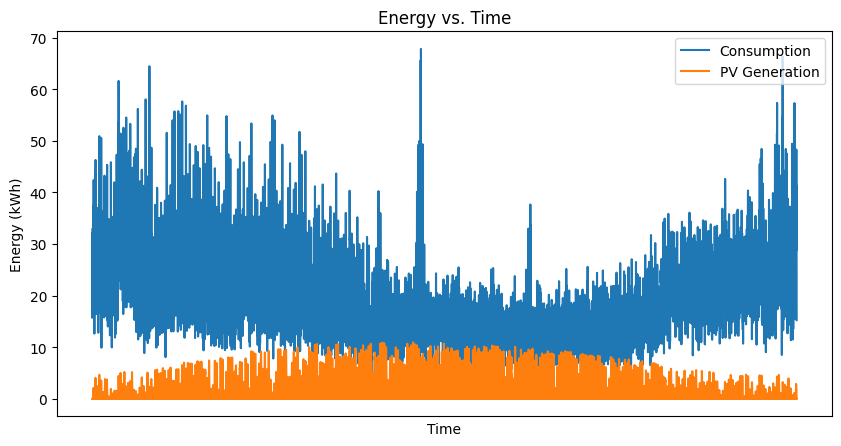

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(pickering['time'], pickering['consumption'], label='Consumption')
plt.plot(pickering['time'], pickering['pv_production'], label='PV Generation')
plt.title('Energy vs. Time')
plt.xlabel('Time')
plt.xticks([])
plt.ylabel('Energy (kWh)')
plt.legend()
plt.show()

In [ ]:
pickering.to_csv('PickeringData.csv')

#Lac Megantic Test

In [ ]:
test = pd.read_csv('LacMeganticTestWeather.csv', skiprows=3)
area = 24 * 7 + 20 * 13 + 90 * 100
test['pv_production'] = calculate_solar_energy(irradiance_w_per_m2=test['shortwave_radiation_instant (W/m²)'], area=area, efficiency=0.25)
#Cell may take a few minutes to run
test['consumption'] = generate_load(test, num_buildings=30, scale_factor=1.5)
test['price'] = .0674

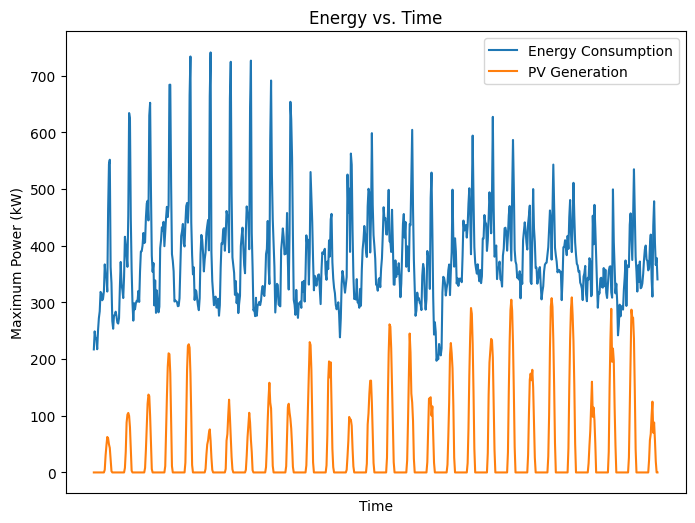

In [ ]:
plt.figure(figsize=(8,6))
plt.plot(test['time'], test['consumption'], label='Energy Consumption')
plt.plot(test['time'], test['pv_production'], label='PV Generation')
plt.title('Energy vs. Time')
plt.xlabel('Time')
plt.xticks([])
plt.ylabel('Maximum Power (kW)')
plt.legend()
plt.show()

In [ ]:
test.to_csv("LacMeganticDataTest.csv")